## SPAD Position Optimization Sweep

This notebook connects to the running qudi instance and performs a **two-phase**
position optimization using `spad_optimize_logic`:

1. **Z sweep** — find the optimal focus by sweeping Z and tracking the 9 brightest
   pixels (one per emitter in the 3×3 array).  The scanner is then moved to the
   peak-Z position.
2. **XY sweep** — at the optimal Z, sweep XY and compute the integrated 9-emitter
   counts using a fixed 5×5-footprint mask (every-other-pixel spacing) anchored to
   the brightest pixel found during the Z sweep.

The feedback between phases ensures the XY sweep is performed at best focus.

**Prerequisites:**
- qudi is running with `spad_optimize_logic`, `spad_probe_logic`, and `camera_SPC3` activated
- The SPC3 camera live view is **stopped** (snap mode requires it)
- Optimizer settings (scan range, resolution) are configured in `scanner_spad_gui`
- The scanner is positioned at the approximate centre of the region of interest

In [17]:
import time
import numpy as np
import matplotlib.pyplot as plt

# Access qudi modules (available in the kernel namespace)
opt      = spad_optimize_logic
spad     = spad_probe_logic
cam      = camera_SPC3
cam_logic = camera_logic

print(f'Scanner position : {dict(spad.scanner_target)}')
print(f'Optimizer running: {opt.optimizer_running}')

Scanner position : {'x': 9.51555e-05, 'y': 0.0001280484, 'z': 0.0001073953}
Optimizer running: False


## Inspect / override optimizer settings

The sweep uses the optimizer settings that are already configured in `scanner_spad_gui`.
You can inspect them below and optionally override range or resolution before starting.

In [18]:
# Current optimizer settings (set via scanner_spad_gui)
print('Scan sequence :', opt.scan_sequence)
print('Scan range    :', {k: f'{v*1e6:.2f} µm' for k, v in opt.scan_range.items()})
print('Number of points:', opt.scan_resolution)
print('Data channel  :', opt.data_channel)
print('NFrames       :', cam._NFrames, ' (frames averaged per position)')
exposure_ms = float(cam.get_exposure()) * 1e3
print('Exposure     :', f'{exposure_ms:.2f} ms' if exposure_ms is not None else '<unavailable>')

# --- Optional: override optimizer settings from notebook ---
# Uncomment and adjust as needed:
#
# opt.set_optimize_settings(
#     data_channel='APD1',
#     scan_sequence=(('x', 'y'), ('z',)),
#     scan_dimension=[2, 1],
#     range={'x': 10e-6, 'y': 10e-6, 'z': 5e-6},     # sweep range per axis (m)
#     resolution={'x': 20, 'y': 20, 'z': 15},          # points per axis
#     frequency={'x': 50, 'y': 50, 'z': 50},            # not used for SPAD sweep, kept for GUI compat
# )

Scan sequence : (('z',),)
Scan range    : {'x': '0.25 µm', 'y': '0.25 µm', 'z': '5.00 µm'}
Number of points: {'x': 10, 'y': 10, 'z': 100}
Data channel  : APD1
NFrames       : 5  (frames averaged per position)
Exposure     : 104.00 ms


## Phase 1 — Z Focus Sweep

Override the scan sequence to Z-only, run the sweep, and find the optimal focus.

The optimizer will:
1. Set `trigger_mode='no_trigger'` on the SPC3
2. Step through the Z grid, snapping NFrames at each position
3. Restore trigger mode and return scanner to the starting position

In [19]:
# Set sequence to Z-only
opt.scan_sequence = (('z',),)
opt.optimizer_sequence_dimensions = (1,)  # ensure GUI has a 1D widget for ('z',)
print('Scan sequence set to:', opt.scan_sequence)

# Start Z sweep
opt.start_optimize()

t0 = time.time()
while opt.optimizer_running:
    time.sleep(0.5)
    elapsed = time.time() - t0
    print(f'\rZ sweep running... {elapsed:.0f}s', end='', flush=True)

elapsed = time.time() - t0
print(f'\nZ sweep complete in {elapsed:.1f}s')

Scan sequence set to: (('z',),)
Z sweep running... 79s
Z sweep complete in 79.1s


## Retrieve & analyse Z sweep

Find the optimal Z by plotting the sum of the 9 brightest pixels vs Z position.
The brightest pixel in the peak-Z frame identifies the centre of the 3×3 emitter
array and will be used as the mask anchor for the XY sweep.

### Z analysis & move to optimal focus

Z sweep: 104.90 – 109.90 µm, 100 points, frames shape (100, 32, 32)


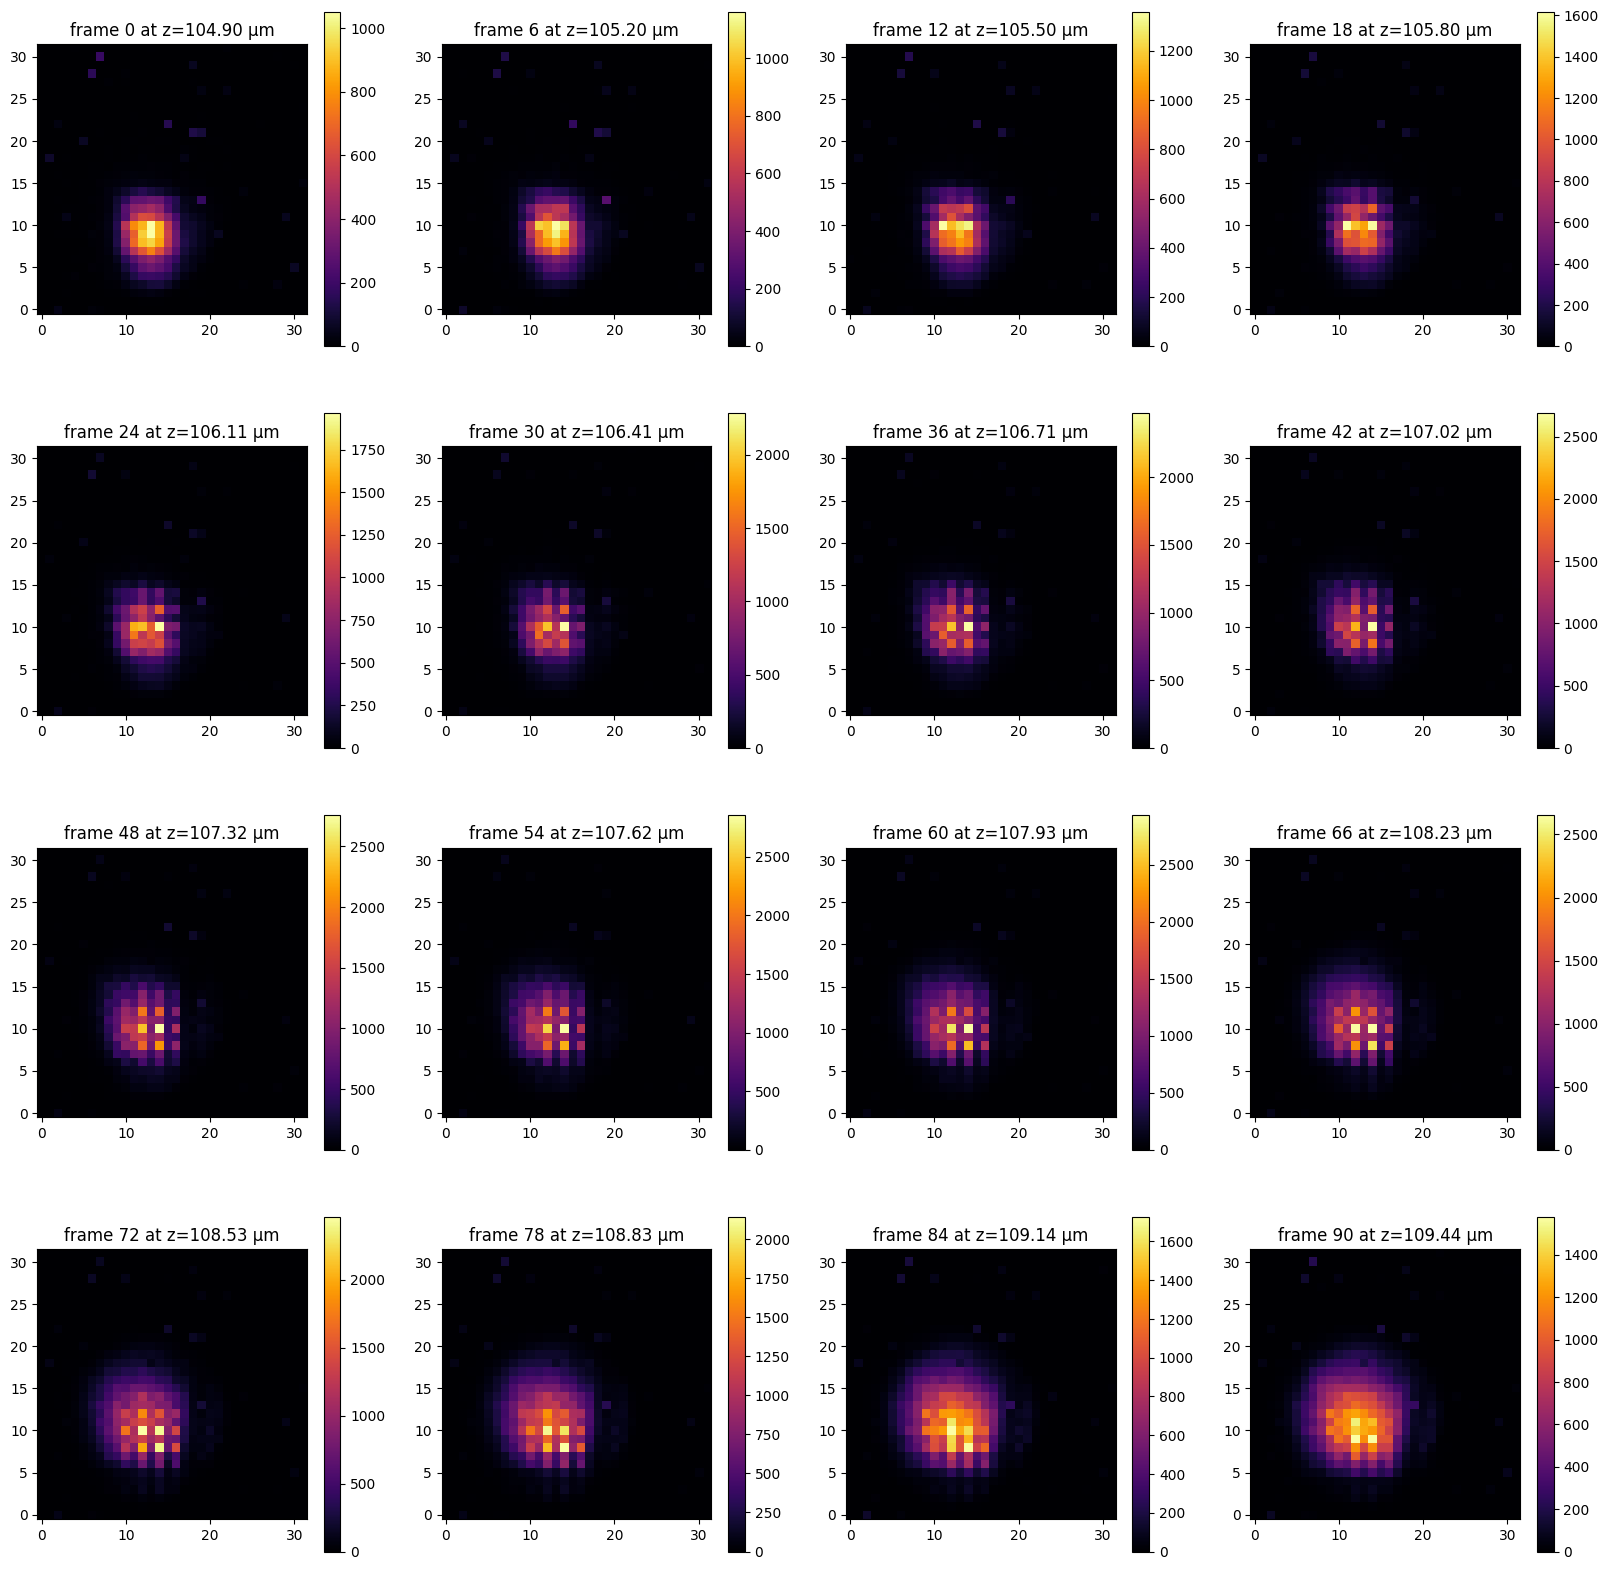

In [20]:
# Retrieve Z sweep data
z_data_remote = opt.spad_scan_data
z_step = {
    'axes':   tuple(z_data_remote[0]['axes']),
    'grids':  {k: np.array(v) * 1e6 for k, v in z_data_remote[0]['grids'].items()},
    'frames': np.array(z_data_remote[0]['frames']),
    'center': {k: v * 1e6 for k, v in z_data_remote[0]['center'].items()},
}

ax = z_step['axes'][0]
z_pos = z_step['grids'][ax]
frames_z = z_step['frames']
print(f'Z sweep: {z_pos[0]:.2f} – {z_pos[-1]:.2f} µm, {len(z_pos)} points, '
      f'frames shape {frames_z.shape}')


plt.subplots(4,4, figsize=(20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    plt.imshow(frames_z[6*i], origin='lower', cmap='inferno')
    plt.title(f'frame {6*i} at z={z_pos[6*i]:.2f} µm')
    plt.colorbar()
plt.show()  

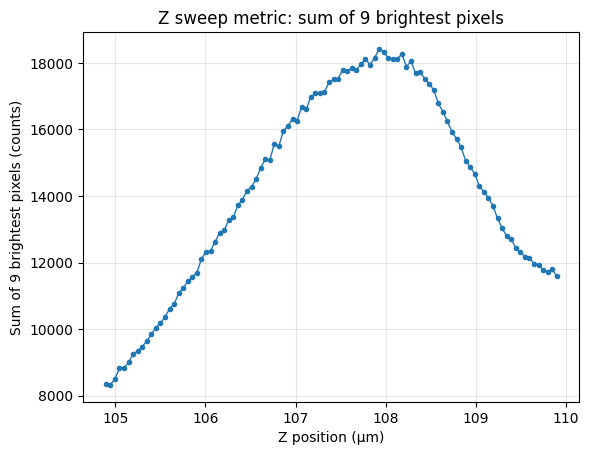

In [21]:
# Sum of the 9 brightest pixels in each Z frame, then plot vs z_pos
# frames_z: (Nz, H, W)
if frames_z.ndim != 3:
    raise ValueError(f"Expected frames_z with shape (Nz, H, W); got {frames_z.shape}")

if len(z_pos) != frames_z.shape[0]:
    raise ValueError(f"len(z_pos)={len(z_pos)} does not match frames_z.shape[0]={frames_z.shape[0]}")

k = 9
flat = frames_z.reshape(frames_z.shape[0], -1)
if flat.shape[1] < k:
    raise ValueError(f"Each frame has only {flat.shape[1]} pixels, cannot take top-{k}.")

# For each frame, take the top-k values without fully sorting
# (np.partition puts the k largest values in the last k positions, in arbitrary order)
bright9_sum = np.partition(flat, -k, axis=1)[:, -k:].sum(axis=1)

plt.figure()
plt.plot(z_pos, bright9_sum, marker='o', ms=3, lw=1)
plt.xlabel('Z position (µm)')
plt.ylabel('Sum of 9 brightest pixels (counts)')
plt.title('Z sweep metric: sum of 9 brightest pixels')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Sum of the 9 brightest pixels in each Z frame, then plot vs z_pos
# frames_z: (Nz, H, W)
if frames_z.ndim != 3:
    raise ValueError(f"Expected frames_z with shape (Nz, H, W); got {frames_z.shape}")

if len(z_pos) != frames_z.shape[0]:
    raise ValueError(f"len(z_pos)={len(z_pos)} does not match frames_z.shape[0]={frames_z.shape[0]}")

k = 1000
flat = frames_z.reshape(frames_z.shape[0], -1)
if flat.shape[1] < k:
    raise ValueError(f"Each frame has only {flat.shape[1]} pixels, cannot take top-{k}.")

# For each frame, take the top-k values without fully sorting
# (np.partition puts the k largest values in the last k positions, in arbitrary order)
bright9_sum = np.partition(flat, -k, axis=1)[:, -k:].sum(axis=1)

plt.figure()
plt.plot(z_pos, bright9_sum, marker='o', ms=3, lw=1)
plt.xlabel('Z position (µm)')
plt.title('Z sweep metric: sum of all pixels')
plt.grid(True, alpha=0.3)
plt.show()

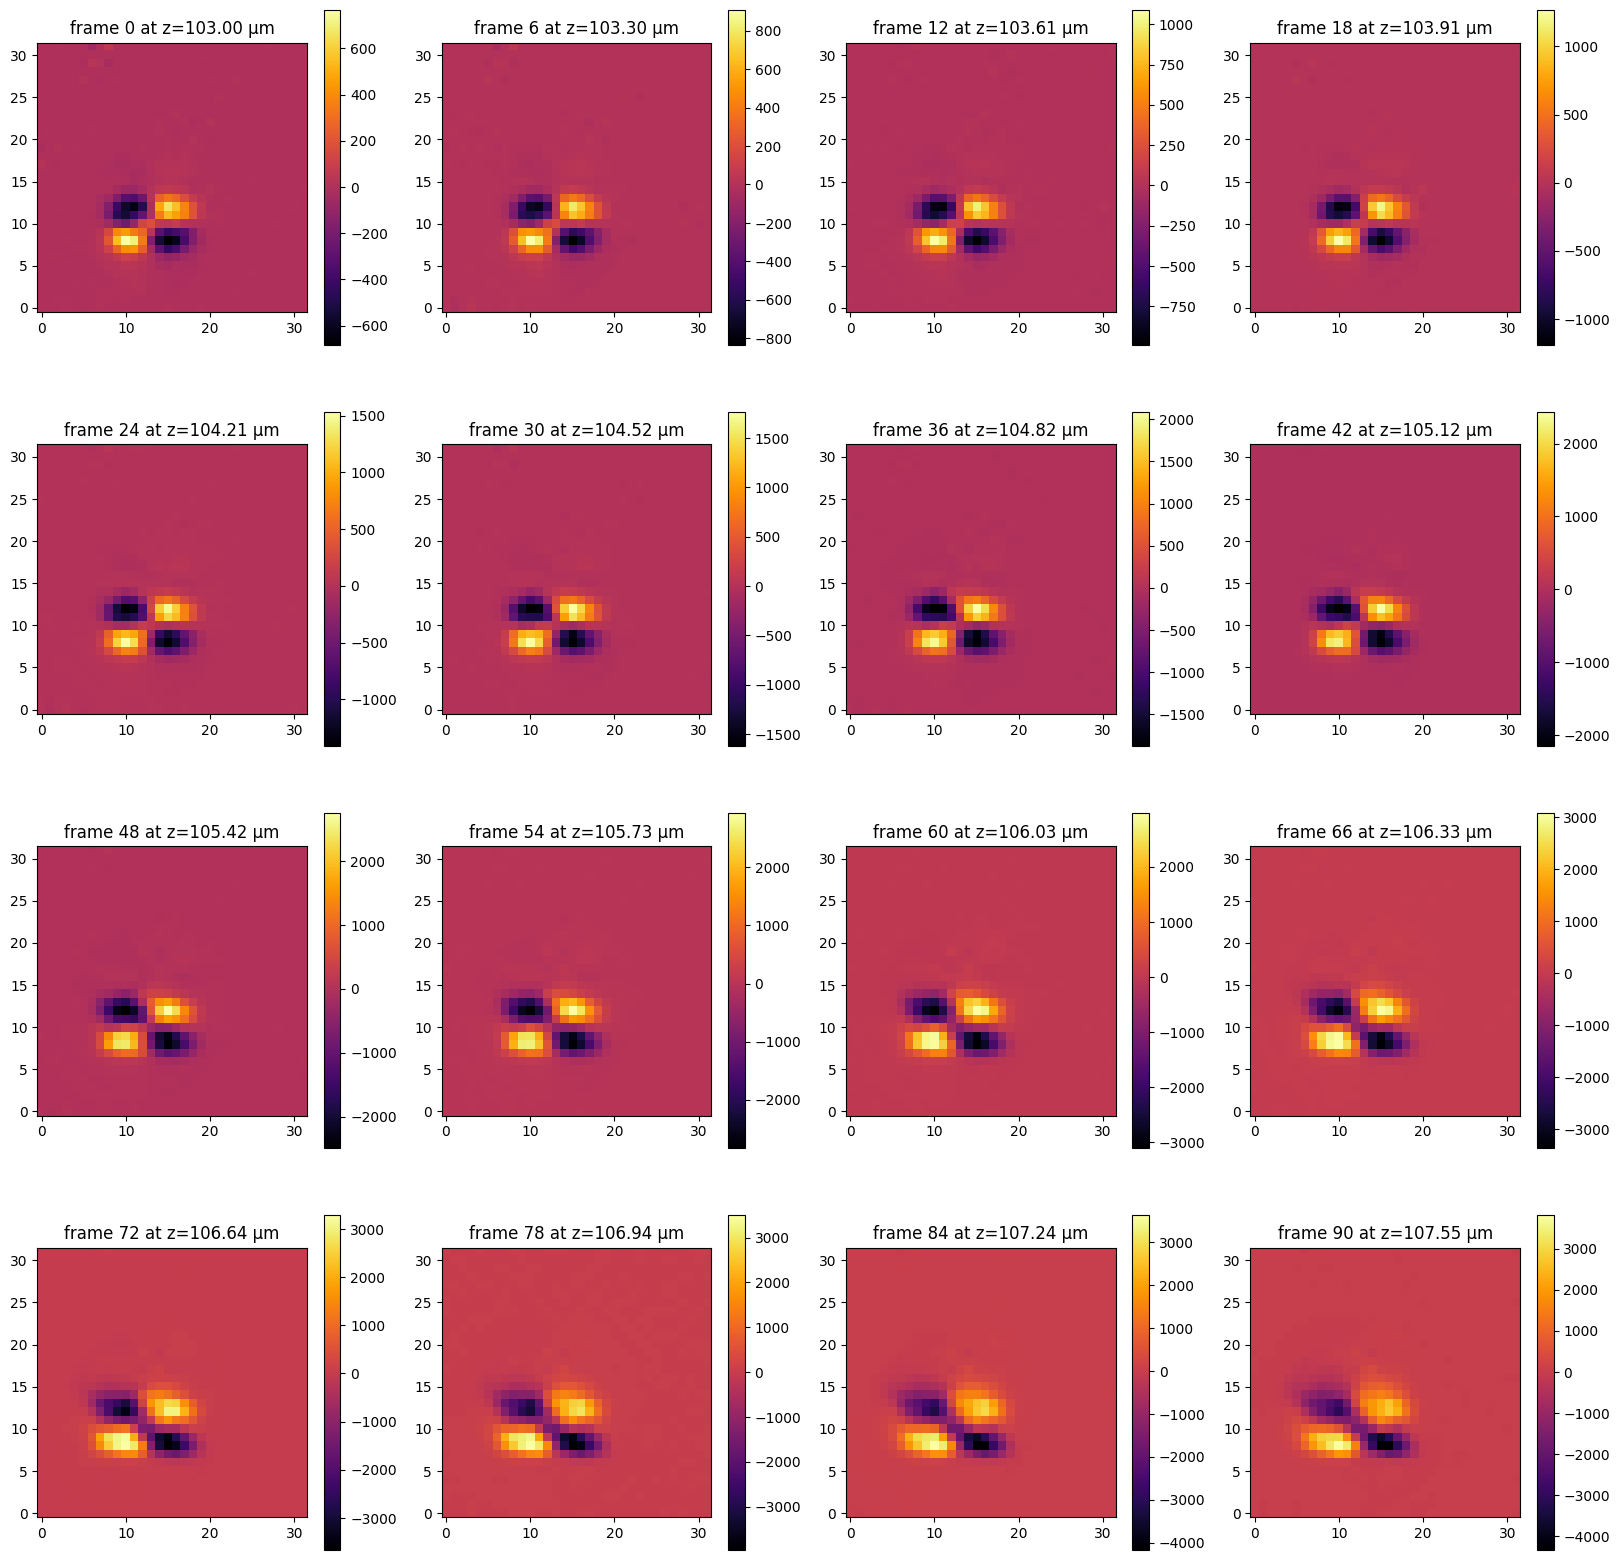

In [11]:
plt.subplots(4,4, figsize=(20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    plt.imshow(np.gradient(np.gradient(frames_z[6*i], axis=0), axis=1), origin='lower', cmap='inferno')
    plt.title(f'frame {6*i} at z={z_pos[6*i]:.2f} µm')
    plt.colorbar()
plt.show()  

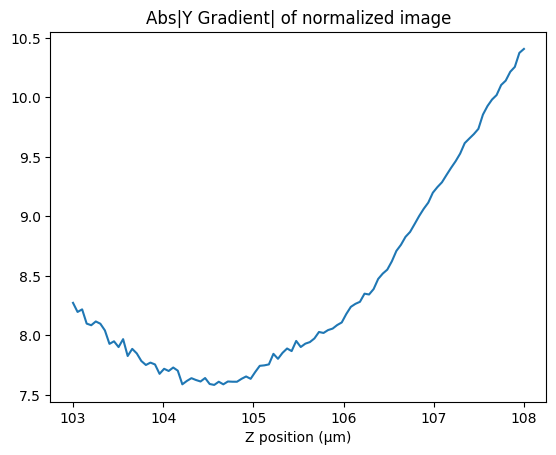

In [13]:
#optimize position using gradient of normalized image 
grad_tot = np.zeros_like(z_pos)
for i in range(len(z_pos)):
    grad_tot[i] = np.abs(np.gradient(frames_z[i]/np.max(frames_z[i]), axis=1)).sum()


plt.figure()
plt.plot(z_pos, grad_tot)
plt.xlabel('Z position (µm)')
plt.title('Abs|Y Gradient| of normalized image')
plt.show()


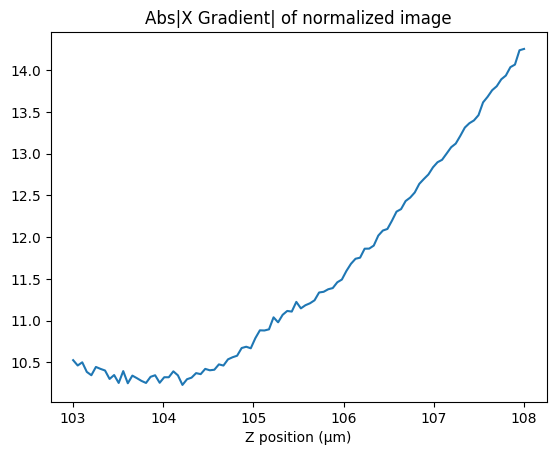

In [14]:
#optimize position using gradient of normalized image 
grad_tot = np.zeros_like(z_pos)
for i in range(len(z_pos)):
    grad_tot[i] = np.abs(np.gradient(frames_z[i]/np.max(frames_z[i]), axis=0)).sum()


plt.figure()
plt.plot(z_pos, grad_tot)
plt.xlabel('Z position (µm)')
plt.title('Abs|X Gradient| of normalized image')
plt.show()


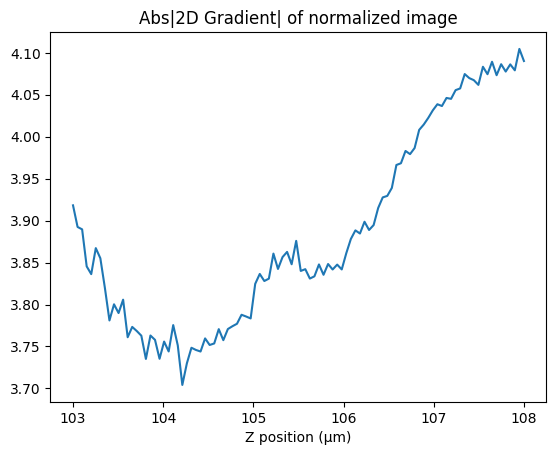

In [16]:
#try 2D gradient #found counts are higher when moving to the optimal here vs above

#optimize position using gradient of normalized image 
grad_tot = np.zeros_like(z_pos)
for i in range(len(z_pos)):
    grad_tot[i] = np.abs(np.gradient(np.gradient(frames_z[i]/np.max(frames_z[i]), axis=0), axis=1)).sum()


plt.figure()
plt.plot(z_pos, grad_tot)
plt.xlabel('Z position (µm)')
plt.title('Abs|2D Gradient| of normalized image')
plt.show()

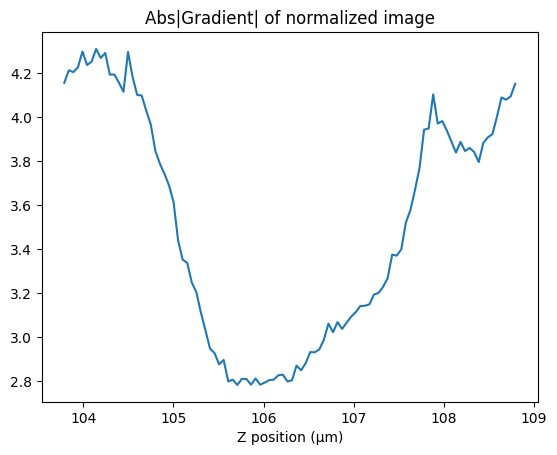

In [8]:
#try 2D gradient #found counts are higher when moving to the optimal here vs above

#optimize position using gradient of normalized image 
# grad_tot = np.zeros_like(z_pos)
# for i in range(len(z_pos)):
#     grad_tot[i] = np.abs(np.gradient(np.gradient(frames_z[i]/np.max(frames_z[i]), axis=0), axis=1)).sum()


# plt.figure()
# plt.plot(z_pos, grad_tot)
# plt.xlabel('Z position (µm)')
# plt.title('Abs|Gradient| of normalized image')
# plt.show()

In [9]:
# plt.subplots(4,4, figsize=(20, 20))

# for i in range(16):
#     plt.subplot(4, 4, i + 1)

#     plt.imshow(np.gradient(frames_z[6*i]/np.max(frames_z[6*i]), axis=0), origin='lower', cmap='inferno')
#     plt.title(f'frame {6*i} at z={z_pos[6*i]:.2f} µm grad {np.abs(np.gradient(frames_z[6*i]/np.max(frames_z[6*i]), axis=1)).sum():.2f}')
#     plt.colorbar()
# plt.show()  

In [27]:
# Set sequence to XY-only
opt.scan_sequence = (('x', 'y'),)
opt.optimizer_sequence_dimensions = (2,)  # ensure GUI has a 2D widget for ('x','y')
print('Scan sequence set to:', opt.scan_sequence)

# Start XY sweep (centred on current scanner position, which is now at optimal Z)
opt.start_optimize()

t0 = time.time()
while opt.optimizer_running:
    time.sleep(0.5)
    elapsed = time.time() - t0
    print(f'\rXY sweep running... {elapsed:.0f}s', end='', flush=True)

elapsed = time.time() - t0
print(f'\nXY sweep complete in {elapsed:.1f}s')

Scan sequence set to: (('x', 'y'),)
XY sweep running... 79s
XY sweep complete in 79.1s


### Retrieve & analyse XY sweep

XY sweep: x 95.03–95.28 µm (10 pts), y 127.92–128.17 µm (10 pts)
  raw frames shape: (10, 10, 32, 32)


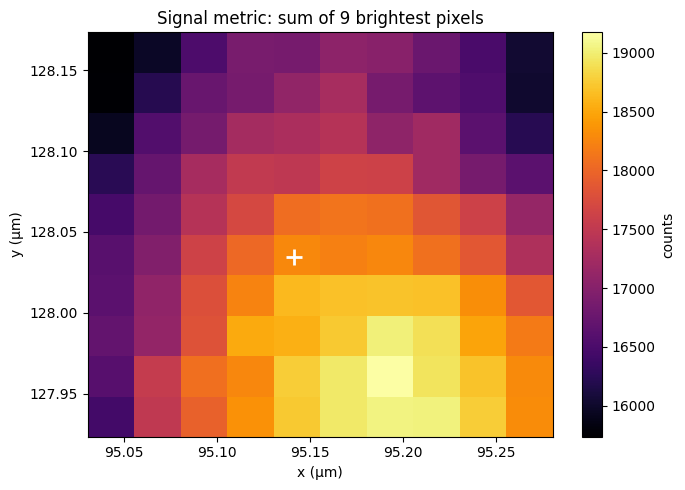

Peak XY (9-brightest metric): (x=95.20 µm, y=127.95 µm)


In [28]:
# Retrieve XY sweep data
xy_data_remote = opt.spad_scan_data
xy_step = {
    'axes':   tuple(xy_data_remote[0]['axes']),
    'grids':  {k: np.array(v) * 1e6 for k, v in xy_data_remote[0]['grids'].items()},
    'frames': np.array(xy_data_remote[0]['frames']),
    'center': {k: v * 1e6 for k, v in xy_data_remote[0]['center'].items()},
}

ax0, ax1 = xy_step['axes']
g0 = xy_step['grids'][ax0]
g1 = xy_step['grids'][ax1]
frames_xy = xy_step['frames']
print(f'XY sweep: {ax0} {g0[0]:.2f}–{g0[-1]:.2f} µm ({len(g0)} pts), '
      f'{ax1} {g1[0]:.2f}–{g1[-1]:.2f} µm ({len(g1)} pts)')
print(f'  raw frames shape: {frames_xy.shape}')

# --- XY metric: sum of the 9 brightest pixels in each frame ---
# frames_xy expected shape: (Nx, Ny, H, W)
if frames_xy.ndim != 4:
    raise ValueError(f'Expected frames array with shape (Nx, Ny, H, W); got {frames_xy.shape}')

have_xy = ('x' in xy_step['grids']) and ('y' in xy_step['grids'])
if not have_xy:
    raise ValueError(f"Expected 'x' and 'y' grids, got keys: {list(xy_step['grids'].keys())}")

x_grid = xy_step['grids']['x']
y_grid = xy_step['grids']['y']
nx, ny = len(x_grid), len(y_grid)

if frames_xy.shape[0] != nx or frames_xy.shape[1] != ny:
    raise ValueError(
        f"frames scan dims are ({frames_xy.shape[0]}, {frames_xy.shape[1]}) but x/y grid lengths are ({nx}, {ny})."
    )

axes = tuple(xy_step['axes'])
if axes != ('x', 'y'):
    raise ValueError(f"Unexpected axes order {axes}; expected ('x','y')")

k = 9
flat_xy = frames_xy.reshape(nx * ny, -1)
if flat_xy.shape[1] < k:
    raise ValueError(f"Each frame has only {flat_xy.shape[1]} pixels, cannot take top-{k}.")

metric_flat = np.partition(flat_xy, -k, axis=1)[:, -k:].sum(axis=1)
metric_xy = metric_flat.reshape(nx, ny)

# Peak index in (nx, ny)
peak_x_idx, peak_y_idx = np.unravel_index(np.nanargmax(metric_xy), metric_xy.shape)

# For plotting we want metric indexed as [y, x]
metric_yx = metric_xy.T  # (ny, nx)

# Keep peak index compatible with the rest of the notebook: peak_xy_idx indexes (ax0, ax1).
idx_by_axis = {'x': int(peak_x_idx), 'y': int(peak_y_idx)}
peak_xy_idx = (idx_by_axis[ax0], idx_by_axis[ax1])

# Scan-range center idx (for reference marker)
center_x_scan = 0.5 * (x_grid[0] + x_grid[-1])
center_y_scan = 0.5 * (y_grid[0] + y_grid[-1])
x_center_idx = int(np.argmin(np.abs(x_grid - center_x_scan)))
y_center_idx = int(np.argmin(np.abs(y_grid - center_y_scan)))

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

extent = [x_grid[0], x_grid[-1], y_grid[0], y_grid[-1]]
im = ax.imshow(metric_yx, origin='lower', aspect='auto', extent=extent, cmap='inferno')
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title('Signal metric: sum of 9 brightest pixels')
fig.colorbar(im, ax=ax, label='counts')

# Mark scan-range center
ax.plot(x_grid[x_center_idx], y_grid[y_center_idx], 'w+', ms=12, mew=2)

plt.tight_layout()
plt.show()

print(f"Peak XY (9-brightest metric): ({ax0}={g0[peak_xy_idx[0]]:.2f} µm, {ax1}={g1[peak_xy_idx[1]]:.2f} µm)")


## Move scanner to optimal XYZ position (optional)

After inspecting both sweep results, move the scanner to the combined optimal position.

In [ ]:
# Move scanner to the optimal XYZ position

optimal_pos = {ax: optimal_z_m}   # Z from phase 1
optimal_pos[ax0] = g0[peak_xy_idx[0]] * 1e-6   # X from phase 2
optimal_pos[ax1] = g1[peak_xy_idx[1]] * 1e-6   # Y from phase 2

print(f'Moving to: { {k: f"{v*1e6:.2f} µm" for k, v in optimal_pos.items()} }')

# Update SPAD scanner
spad.set_target_position(optimal_pos, move_blocking=True)

# Update confocal scanner so both GUIs stay in sync
scanning_probe_logic.set_target_position(optimal_pos, move_blocking=True)

print('Done — both SPAD and confocal scanners updated.')